# Chapter 2: Neural Language Modeling

In the first chapter, we saw how to build Markov models to generate text. We also saw that one of their main limitations is the problem of modeling long-range sequences. In the second chapter, we learn how we can use Deep Learning to build models that can learn through data. In this chapter, we will see how we can use deep learning to improve the Markov model.

<img src="./img/gate.png" alt="Neuron" width="800" height="400">

The problem with Markov chains is that the next token probability is only based on the previous token or tokens. To improve our modeling capacity, we need to be able to produce a different probability distribution based on the current state of the token. For example, the probability of the tokens inside an if statement is different from the probabilities inside a loop or a function definition.

## Neural Markov

Let's start by recreating the Markov model using neural networks. Let's use the same text from the first chapter.

In [1]:
import requests
from bs4 import BeautifulSoup
import re

url = 'https://en.wikipedia.org/wiki/Computer'
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
doc = BeautifulSoup(response.text, 'html.parser')
text = '\n'.join([x.text for x in doc.find('div', {'id': 'bodyContent'})])
cleaned_text = re.sub(r'\n+', '\n', text)

Then, the same tokenization and vocabulary building functions.

In [2]:
import itertools

def tokenize(text, n_grams, sliding=True):
    if not sliding:
        return [''.join(x) for x in itertools.batched(text, n_grams)]

    tokens = []
    for i in range(len(text) - n_grams + 1):
        tokens.append(text[i:i+n_grams])
    return tokens

def build_vocab(tokens):
    vocab = list(set(tokens))
    wi = {c: i for i, c in enumerate(vocab)}
    iw = {i: c for i, c in enumerate(vocab)}
    return wi, iw

Let's build our training data by tokenizing the text and building the vocabulary. We will use n-grams of size 1 for now:

In [3]:
n_grams = 1
tokens = tokenize(cleaned_text, n_grams)
wi, iw = build_vocab(tokens)
print('Vocabulary size:', len(wi))
print('Number of tokens:', len(tokens))

Vocabulary size: 108
Number of tokens: 103341


Now we can build our training data. Our objective will be to predict the next token given the previous token. This is the same architecture we used to train a classifier in the second chapter. But instead of 3 flower classes, each token in our vocabulary will be a class:

<div>
    <img src="https://mermaid.ink/img/pako:eNqtUstOwzAQ_BVrz3kR203sAyot4saNE8rFNM4DJXHkOGohzb9jJ1Sg3oqwpfXu7M7sHDzBQeUSOBSNOh4qoQ3avWQdsudpOzXiTTYcZRAFFJ1RFKRLxEu8y2BGvn9_LqQwo5bDGT1brWZlL6lro4fthOq2dDKVMf3Aw7BuRSmHoJcn2QzBQbVhXymjhjBJI4xTGq4df0H9bzB472WZgYd6NTgx4_IjR5vIQ9X6HFQ3GC3qzrgB1WWA5ms7u1vsYBaTiF3ZWcF_srO_wQ6mLKFxfOXngv7Z0OU6Y-BBqescuNGj9KCVuhWuhMn1rWglW5mBo-eyEGNjt2TdbGm96F6Vai9MrcayAl6IZrDV2OfCyMdalFr8jMgul3qvxs4Ap4sC8AlOtkgDvEkSTCiNYkoIJR58WJgFBCeEpoxgzCLGZg8-l532ZyaE_T7zF9x83dA?type=png">

<img src="https://mermaid.ink/img/pako:eNpdjk1PwzAMhv9K5HNXlSWhbQ4IMcSNGyeUi7e47aQ0mbJEfHT97zSdQGj2xe9jv7YnOHhDoKCz_uMwYIjs6U07tsTL42RxT1YxDTsNM9tsHi4dYUyBzhf2uvjsdXItc5vhLdjfAq_dNTOGAvpwNKBiSFTASGHELGHKfQ1xoJE05A8MdZhs1KDdvNhO6N69H3-dwad-ANWhPS8qnQxGej5iH3D8o4GcobDzyUVQW7nuADXBJyjZlPy-rrmQstpKIaQo4GvBbSl4LWTTCs7bqm3nAr7Xq1XZ1LL6F3fzD9_jYhw?type=png">

</div>

With this architecture, we can generate text in a similar way to our first Markov model; we predict the next token, and then we feed it back to the input to continue the generation.

Let's build this example starting with the training dataset. We can write a function that, given a sequence of tokens $x$, predicts the next token $y$.


In [4]:
import torch
from torch.utils.data import TensorDataset

def build_dataset(tokens, sequence_length=1, slide=1):

    x = []
    y = []

    for i in range(0, len(tokens) - sequence_length, slide):
        x.append([wi[q] for q in tokens[i:i+sequence_length]])
        y.append(wi[tokens[i+sequence_length]])

    return TensorDataset(torch.LongTensor(x), torch.LongTensor(y))

dataset = build_dataset(tokens, sequence_length=1, slide=1)
print(len(dataset))

103340


Now we can build our model. We will use a linear layer with input size 1 (the current token) and output size equal to the vocabulary size (the next possible tokens). Then, to compute the probability distribution, we will apply a log softmax to the output of the linear layer. This is the same architecture we used to train a classifier in the second chapter, but now, instead of 3 classes, we have as many classes as tokens in our vocabulary.

In [5]:
import torch.nn as nn

class NeuralMarkov(nn.Module):
    def __init__(self, vocab_size):
        super(NeuralMarkov, self).__init__()
        self.lm = nn.Sequential(
            nn.Linear(1, vocab_size),
            nn.LogSoftmax(dim=-1)
        )

    def forward(self, x):
        return self.lm(x.float())

Our training function is the same as the one used in the last chapter to train the Iris classifier.

In [6]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

def train(model, dataset, epochs=10, batch_size=16, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss()
    lh = []
    progress = tqdm(total=len(dataset) * epochs)
    for epoch in range(epochs):
        el = []
        for (x, y) in DataLoader(dataset, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            o = model(x)
            loss = crit(o, y)
            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

Now we can train our model using the train function:

  0%|          | 0/1033400 [00:00<?, ?it/s]

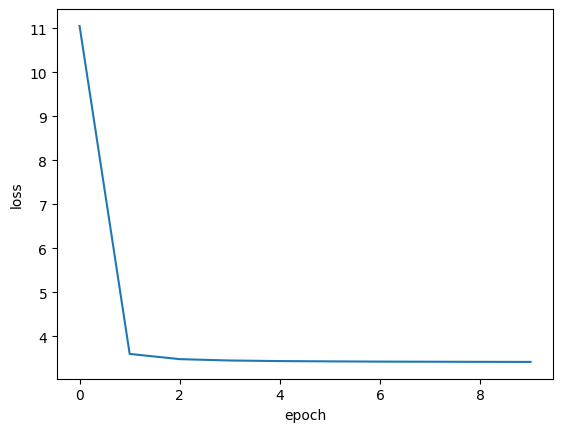

In [7]:
vocab_size = len(wi)
model = NeuralMarkov(vocab_size)
train(model, dataset, epochs=10, batch_size=32, lr=0.001)

We can see that our loss got stuck around 3.5. This is because our model is not able to model our text correctly since it only sees the previous token. Also, the loss is correlated with the perplexity of the model. A lower loss corresponds to lower perplexity, and from the experiments in the first chapter, we know that increasing the n-gram size decreases the perplexity.

Generating text with this model follows the same procedure as our Markov model. We start with a seed token, and then we get the probabilities of the next token using our model. We sample from the probability distribution to get the next token, and then we append it to the input text.

In [8]:
def gen(model, text, max_tokens=100):
    # convert our text tokens to tensors
    x = torch.LongTensor([wi[text]]).unsqueeze(0)

    for _ in range(max_tokens):
        with torch.no_grad():
            # sample the probabilities of the next tokens
            log_probs = model(x)

        # our probabilities are in log space, so we take the exp
        probs = log_probs.exp()

        # the next token is the one with the highest probability
        next_token = probs.argmax().item()

        # append the generated token to the text
        text += iw[next_token]

        # the next token is now the current token
        x = torch.LongTensor([next_token]).unsqueeze(0)

    return text

Let's see how our model generates text:

In [9]:
text = 'C'
generated_text = gen(model, text, max_tokens=100)
print(generated_text)

C                                                                                                    


It is possible that our model enters a loop and generates the same token over and over again. To avoid this, we can apply the same solution we used in the first chapter and sample from the probability distribution instead of taking the token with the highest probability.

In [10]:
def gen(model, text, max_tokens=100):
    x = torch.LongTensor([wi[text]]).unsqueeze(0)

    for _ in range(max_tokens):
        with torch.no_grad():
            log_probs = model(x)

        probs = log_probs.exp()

        # we sample from the distribution instead of getting the most probable token every time
        next_token = torch.multinomial(probs, 1).item()

        text += iw[next_token]
        x = torch.LongTensor([next_token]).unsqueeze(0)

    return text


text = 'C'
generated_text = gen(model, text, max_tokens=100)
print(generated_text)

Can nanoterCe
imor.− unrc]5rhtCne,a1s eie c.s,cinlupoSgRwher9  c-olcimwc9eJ
s omt tgFa^ienn.o ru oSnr


---

By sampling from the distribution, we can get more diverse text that helps escape generation loops.

We can see in the generated text example that the model is able to model the space between words, but the words themselves are not being generated correctly. We already know that increasing the n-grams can improve the generation quality, but it won't solve the main problem of long-range dependencies. To solve this, let's improve our neural architecture.

Remember from the last chapter that neural networks don't like unormalized data. And we are using the token indices as input to our model, which makes it difficult for our model, as tokens with higher indices will have higher rotations from the linear layers. But how can we normalize our input data? Since our data is made of tokens that are a type of categorical data, we can use one-hot encoding to normalize our data.

With one-hot encoding, we can represent our categories with a numerical vector. It works by creating a vector of zeros with the same length as the number of categories, and then we set the index of the category to 1. For example, suppose we have a vocabulary of 3 letters: A, B, and C. We start a vector of zeros for each category, like this table:

| | A | B | C |
|---|---|---|---|
| A | 0 | 0 | 0 |
| B | 0 | 0 | 0 |
| C | 0 | 0 | 0 |

Then we set to 1 each column index for each category:

| | A | B | C |
|---|---|---|---|
| A | 1 | 0 | 0 |
| B | 0 | 1 | 0 |
| C | 0 | 0 | 1 |

This helps our model learn better as the norm of our data is always 1. Let's implement this in our model:

In [11]:
class NeuralMarkov(nn.Module):
    def __init__(self, vocab_size):
        super(NeuralMarkov, self).__init__()
        self.lm = nn.Sequential(
            # the input size is now the size of the vocabulary
            nn.Linear(vocab_size, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.vocab_size = vocab_size

    def forward(self, x):
        # converting our token indices to one-hot encoding
        one_hot = nn.functional.one_hot(x, self.vocab_size).float()
        return self.lm(one_hot.squeeze(1))

  0%|          | 0/1033400 [00:00<?, ?it/s]

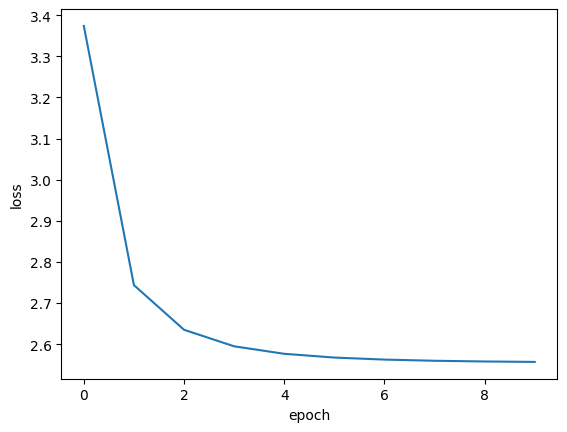

In [12]:
vocab_size = len(wi)
model = NeuralMarkov(vocab_size)
train(model, dataset, epochs=10, batch_size=32, lr=0.001)

Our model is now able to have a lower loss due to the normalization of the input data. Let's see how our model generates text now:

In [13]:
s = 'C'
txt = gen(model, s, max_tokens=100)
print(txt)

CPesU.[3 eshe stecaty.
Eliminded con.
^ l mbagrue m sy, in t me inthif m codoogicesosoizzaronick 20).


---

While the loss is lower, we can't see a significant improvement in the generated text. This is because our model is still only looking at the previous token to predict the next one. To improve our model, we need to increase the context size, that is, the number of previous tokens that our model looks at to predict the next token. For this, we can use the same approach we used to improve our Markov model in the first chapter by using a fixed sequence of tokens to predict the next token.

Implementing this in our model is straightforward, as we can just concatenate the one-hot encodings of the previous tokens in the sequence and feed this larger vector to our linear layer. For example, suppose we have a sequence of 4 tokens with a vocabulary size of 3. So each token will be encoded as a one-hot vector of size 3, and concatenating all tokens gives us a final vector of 12 elements.

Let's first build our dataset with a sequence of 4 tokens as input and the next token as output:

In [14]:
dataset = build_dataset(tokens, sequence_length=4, slide=1)
print(len(dataset))
print(dataset[0][0].shape)

103337
torch.Size([4])


Now we have our dataset with sequences of 4 tokens as input and the next token as output.

To implement this larger context in our model, we multiply the input size of our linear layer by the context size and concatenate the one-hot encodings.

In [15]:
class NeuralMarkov(nn.Module):
    def __init__(self, vocab_size, context_size=4):
        super(NeuralMarkov, self).__init__()
        self.seq = nn.Sequential(
            # the input size is now the context window size multiplied by the vocabulary size
            nn.Linear(vocab_size * context_size, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.vocab_size = vocab_size

    def forward(self, x):
        one_hot = nn.functional.one_hot(x, num_classes=self.vocab_size).float()
        # concatenating the one-hot vectors
        flatten = torch.flatten(one_hot, start_dim=1).unsqueeze(1)
        return self.seq(flatten)[:, -1]

  0%|          | 0/1033370 [00:00<?, ?it/s]

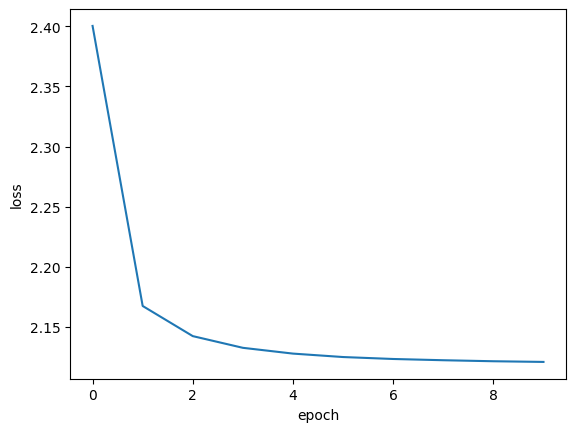

In [16]:
vocab_size = len(wi)
# setting also the context size
model = NeuralMarkov(vocab_size, context_size=4)
train(model, dataset, epochs=10, batch_size=32, lr=0.01)

The greater context gives us lower loss. Let's test our model.

In [17]:
def gen(model, text, max_tokens=100):
    x = torch.LongTensor([wi[q] for q in text]).unsqueeze(0)
    for _ in range(max_tokens):
        with torch.no_grad():
            log_probs = model(x)

        probs = log_probs.exp()

        next_token = torch.multinomial(probs, 1).item()
        text += iw[next_token]
        x = torch.cat([x[:, 1:], torch.LongTensor([[next_token]])], dim=1)

    return text

s = 'Comp'
txt = gen(model, s, max_tokens=200)
print(txt)

Complo uleciand Sif wath re f aniche.
IIBC (2056). ILSIC, Zuse's Calcuacos giann pateraical
Compurasutar (an)". Thay Pags
BRot anectoby by thon lotid he trenumber 20 ACR, Piccoppcabous dork Istleritesieds


---

With a larger context, the model is not able to model some dates and numbers correctly. Also, some small words like "for", "of", "the", "or", etc.

At this point, our model carries the same problem as our Markov model, but with an additional problem. By increasing the vocabulary size, we also increase the input size of our linear layer by the same factor. For example, with n-gram = 2, we have about 2000 tokens. A one-hot encoding for a context size of 4 will give us an input vector of size 8000 composed of 7998 zeros and 2 ones. Vectors like this that have a lot of zeros are called sparse vectors and are inefficient since we need to apply computation on them anyway. To solve this problem, we can use the knowledge gained from the autoencoders from the last chapter.

## Word Embeddings

We saw in the last chapter that autoencoders can be used to learn a compressed representation of our data. Those representations are called embeddings that are vectors in the latent space learned by the autoencoder.

![](./img/auto.png)

This compressed representation contains the semantic information in a compressed state that has enough information used to later reconstruct the original data. We can use this same idea to learn a compressed representation of our sentence. But since sentences can have multiple sizes, let's apply this technique to learn compressed representations of words. To see how it works.

The first step is breaking our text into words instead of n-grams. For this, we can write a simple word tokenizer that splits the text into alphanumeric tokens and punctuation tokens:

In [18]:
def tokenize_word(txt):
    tokens = []
    last_word = None
    for c in txt:
        if c.isalnum():
            if last_word is not None:
                last_word += c
            else:
                last_word = c
        else:
            if last_word is not None:
                tokens.append(last_word)
                last_word = None
            if not c.isspace():
                tokens.append(c)
    if last_word is not None:
        tokens.append(last_word)
    return tokens

In [19]:
word_tokens = tokenize_word(cleaned_text)
word_vocab = set(word_tokens)
wv = list(word_vocab)
word_index = {w: i for i, w in enumerate(wv)}
index_word = {i: w for i, w in enumerate(wv)}

print('Token count:', len(word_tokens))
print('Vocabulary size:', len(wv))

Token count: 21010
Vocabulary size: 4319


Now we can encode our tokens as indices from our vocabulary:

In [20]:
i_tokens = [word_index[w] for w in word_tokens]

The embeddings generated by the autoencoder are trained from input features and are compressed using the reconstruction loss. Another strategy is starting with random embeddings for each feature and then iteratively refining them to the desired objective.

Embeddings in this case are just a matrix of size (vocab_size, embedding_dim) where each row is the embedding of a token in our vocabulary. The implementation is as simple as:

In [21]:
# token indices
words = torch.LongTensor([1, 4, 2])

# Embeddings for a vocabulary of 5 tokens with an embedding dimension of 3
embeddings = torch.Tensor([[0, 0, 0],
                           [1, 1, 1],
                           [2, 2, 2],
                           [3, 3, 3],
                           [4, 4, 4]])

# getting the embeddings for the given token indices
word_embeddings = embeddings[words]
print(word_embeddings)

tensor([[1., 1., 1.],
        [4., 4., 4.],
        [2., 2., 2.]])


In PyTorch, there is a built-in layer called `nn.Embedding` that does exactly this. It initializes the weights randomly from the default. Let's initialize the weights in the same way as the previous examples to compare the two approaches:

In [22]:
# creating an embedding layer with a vocabulary size of 5 and an embedding dimension of 3
embeddings = nn.Embedding(5, 3)
# initializing the data as before
embeddings.weight.data = torch.Tensor([[0, 0, 0],
                                      [1, 1, 1],
                                      [2, 2, 2],
                                      [3, 3, 3],
                                      [4, 4, 4]])

# selecting the embeddings
words = torch.LongTensor([1, 4, 2])
word_embeddings = embeddings(words)

print(word_embeddings)

tensor([[1., 1., 1.],
        [4., 4., 4.],
        [2., 2., 2.]], grad_fn=<EmbeddingBackward0>)


With this layer, we can create our model that will just select and return the embeddings for the given token indices. This technique is called word2vec and is a common technique used in natural language processing to learn word embeddings.

In [23]:
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64):
        super(Word2Vec, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.drop = nn.Dropout(0.2)

    def forward(self, x):
        return self.drop(self.embeddings(x))

Now we have our model, but how will we train our embeddings? The training in Word2Vec follows the distributional hypothesis that says that words occurring in similar contexts have similar meanings.

For this implementation, we will consider that words next to each other are in the same context. So we will train our model to predict the neighboring words given a center word. For example, if we have the sentence "A fish in a river", looking at the word "in," we can consider its context $n$ words to the left and $n$ words to the right. So if we have a context window of size 2, the context of "in" will be ["A", "fish", "a", "river"].

Since both "fish" and "river" are similar to "in", this will make the embeddings of "fish" and "river" also similar to each other. So we can train our model to increase the similarity between words in the same context.

However, we also need to reduce the similarity between words that are not in the same context. But this is a difficult task since we don't know which words are not in the same context. To solve this problem, we can just sample random words from our vocabulary and consider them as negative examples.

Let's build our dataset for this training. We will create pairs of center words and context words as positive examples, and during training, we will sample random words as negative examples.

In [24]:
def build_word_dataset(tokens, window=5):
    # center words
    x = []
    # context words
    y = []

    # the context window size is the number of words to the left and right of the center word
    ws = window // 2
    for i in range(ws, len(tokens) - ws):
        for j in range(i - ws, i + ws + 1):
            # the word is already similar to itself, so skipping equal indexes
            if j != i:
                y.append(tokens[j])
                x.append(tokens[i])

    return TensorDataset(torch.LongTensor(x), torch.LongTensor(y))

dataset = build_word_dataset(i_tokens, window=5)
print(len(dataset))

84024


With our dataset, we are ready to train our model. In this case, we will use the cosine similarity between the embeddings of the center word and the context words as our loss function. We will maximize the cosine similarity for the positive examples and minimize it for the negative examples. The cosine similarity loss reduces the angle between the embeddings if the similarity is one, and reduces the angle if the similarity is -1. In this case, embeddings pointing in the same direction will have similar meanings.

In [26]:
def train_emb(model, dataset, epochs=5, batch_size=16, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # cosine similarity loss
    crit = nn.CosineEmbeddingLoss()

    progress = tqdm(total=len(dataset) * epochs)
    lh = []
    for _ in range(epochs):
        el = []
        for x, y in DataLoader(dataset, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()

            # embeddings of center words
            center_embeddings = model(x)
            # embeddings of context words
            positive_embeddings = model(y)
            # sampling random embeddings
            negative_samples = model(torch.randint(0, model.embeddings.num_embeddings, y.shape))

            # similarity between center words and context must be 1
            pos_loss = crit(center_embeddings, positive_embeddings, torch.ones(x.shape[0]))
            # similarity between center words and random samples must be -1
            neg_loss = crit(center_embeddings, negative_samples, -torch.ones(x.shape[0]))
            # final loss is reducing both positive and negative losses
            loss = pos_loss + neg_loss

            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

  0%|          | 0/840240 [00:00<?, ?it/s]

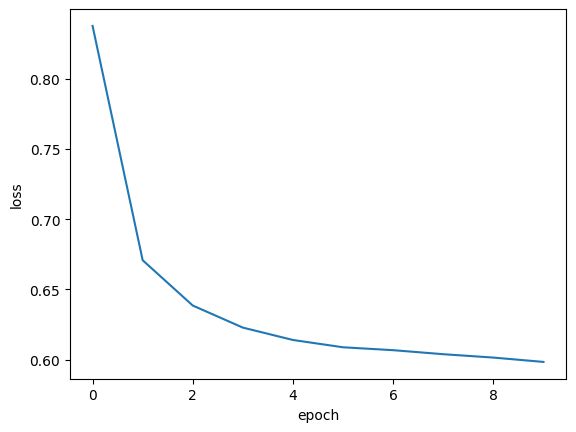

In [27]:
model = Word2Vec(len(word_vocab), embedding_dim=64)
train_emb(model, dataset, epochs=10, batch_size=32, lr=0.01)

Now that our model is trained, let's see some applications of our word embeddings. The first one is finding semantically similar words. We can do this by computing the cosine similarity between the embeddings of the words in our vocabulary and the embedding of a given word. The words with the highest cosine similarity will be the most similar to the given word.

In [28]:
model.eval()

# all words in the vocabulary
word_indexes = list(range(0, len(word_vocab)))

with torch.no_grad():
     word_embeddings = model(torch.LongTensor(word_indexes))

print(word_embeddings.shape)

torch.Size([4319, 64])


Now let's see what words are similar to the word "computer".

In [29]:
word = 'computer'

selected_word_embedding = word_embeddings[word_index[word]].unsqueeze(0)

The cosine similarity is the cosine of the angle between two vectors. We can compute this by computing the dot product of the vectors and then normalizing by their modules. The dot product is defined by:

$$ \vec{a} \cdot \vec{b} = |\vec{a}| |\vec{b}| \cos(\theta) $$


In [30]:
# dot product
dot = selected_word_embedding @ word_embeddings.T
# normalizing
dot /= selected_word_embedding.norm(dim=-1) * word_embeddings.norm(dim=-1)

sim = dot.squeeze().tolist()

Now getting the top 10 most similar words.

In [31]:
similar_words = sorted(zip(sim, word_indexes), reverse=True)[:10]
for sim, idx in similar_words:
    print(f"{index_word[idx]}: {sim:.4f}")

computer: 1.0000
program: 0.9915
first: 0.9889
digital: 0.9886
the: 0.9882
in: 0.9873
was: 0.9863
stored: 0.9861
control: 0.9860
electronic: 0.9854


We can see that a computer is similar to itself and also to words like "digital", "program", "electronic", "hardware", etc.

Another application is that we can "combine" the semantics of two words by adding their embeddings. This will result in a vector that points at the angle between the two original vectors.

Let's see what the most similar words to the combination of "program" and "hardware" are.

In [32]:
word1 = word_index['program']
word2 = word_index['hardware']

emb1 = word_embeddings[word1].unsqueeze(0)
emb2 = word_embeddings[word2].unsqueeze(0)

combined_embedding = emb1 + emb2

dot = combined_embedding @ word_embeddings.T
dot /= combined_embedding.norm(dim=-1) * word_embeddings.norm(dim=-1)

sim = dot.squeeze().tolist()

similar_words = sorted(zip(sim, word_indexes), reverse=True)[:10]
for sim, idx in similar_words:
    # ignoring the initial words
    if idx in {word1, word2}:
        continue
    print(f"{index_word[idx]}: {sim:.4f}")

computer: 0.9926
the: 0.9896
control: 0.9888
digital: 0.9883
of: 0.9878
first: 0.9877
in: 0.9874
computers: 0.9866


We have in this case that "computer" is in the first place. Of course, we have a very small text corpus. But with a larger corpus, those embeddings can better capture more relations between other words.

Since we can combine the meaning of multiple words, we can use this to compute the similarity between two sentences by adding the embeddings of the words in the sentence and then computing the cosine similarity between the resulting vectors. Since adding also increases the module of the resulting vector, we can compute the mean of the vectors instead. Let's write a function to compute the embedding of a sentence and another to compute the similarity between them.

In [33]:
def sentence_embedding(sentence):
    tks = tokenize_word(sentence)
    with torch.no_grad():
        embs = model(torch.LongTensor([word_index[w] for w in tks]))

    return embs.mean(dim=0, keepdim=True)

def sentence_similarity(emb1, emb2):
    dot = emb1 @ emb2.T
    dot /= emb1.norm(dim=-1) * emb2.norm(dim=-1)
    return dot.item()

In [34]:
sentence1 = 'A computer is a machine.'
sentence2 = 'More specialized analog calculations.'
sentence3 = 'The development progressed.'

emb1 = sentence_embedding(sentence1)
emb2 = sentence_embedding(sentence2)
emb3 = sentence_embedding(sentence3)

s1 = sentence_similarity(emb1, emb2)
s2 = sentence_similarity(emb1, emb3)

print(f'Similarity between sentence1 and sentence2 is: {s1:.2f}')
print(f'Similarity between sentence1 and sentence3 is: {s2:.2f}')

Similarity between sentence1 and sentence2 is: 0.94
Similarity between sentence1 and sentence3 is: 0.90


In this example the sentence 1 is slightly more similar to sentence 2 than to sentence 3. With this simple approach, we can capture some semantic information about the sentences. However, we have a problem with homonyms, which are words that have multiple meanings. In our example, the same input always gets the same embedding. We can solve this problem later.

Let's now replace our one-hot encoding in our Neural Markov model with embedding and learn them together with the next token prediction task.

In [35]:
class NeuralMarkov(nn.Module):
    def __init__(self, vocab_size, n_dim=64, context_size=4):
        super(NeuralMarkov, self).__init__()
        # embedding layer instead of one-hot encodings
        self.emb = nn.Embedding(vocab_size, n_dim)
        self.seq = nn.Sequential(
            nn.Linear(n_dim * context_size, n_dim),
            nn.ReLU(),
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.vocab_size = vocab_size

    def forward(self, h):
        emb = self.emb(h)
        flatten = torch.flatten(emb, start_dim=1)
        return self.seq(flatten)

  0%|          | 0/1033370 [00:00<?, ?it/s]

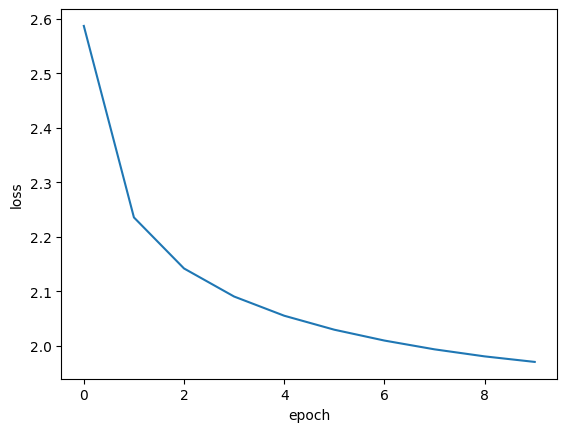

In [36]:
n_grams = 1
tokens = tokenize(cleaned_text, n_grams)
wi, iw = build_vocab(tokens)

dataset = build_dataset(tokens, sequence_length=4, slide=1)

nm = NeuralMarkov(len(wi), n_dim=32, context_size=4)
train(nm, dataset, epochs=10, batch_size=32, lr=0.001)

Our model with embeddings reached a lower loss with fewer parameters. Let's see how it generates text:

In [37]:
s = 'Comp'
txt = gen(nm, s, max_tokens=100)
print(txt)

Computers
Idifal enegrate ald ROMine rous and dugien mia 2026-8
Babpofionted peschine Cowpongshival, Tul


Our model is now able to reach a smaller loss with fewer parameters. But we haven't solved the problem of long-range dependencies. But knowing that embeddings can capture semantic information, and we can produce them with neural models, we can design a more complex architecture that can solve this problem.

## Recurrent Neural Networks

Knowing that embeddings can capture semantic information and that we can combine them to create new embeddings, we can design an architecture capable of generating a different probability distribution for the next token based on the current state. This will allow us to better model text. For example, in generating code, the model will learn that the probabilities inside a function are different from the probabilities inside a for loop.

Lets built it iteratively, starting with the current token:


In [38]:
current_token = torch.LongTensor([wi['C']])
print(current_token)

tensor([1])


Then we need to get the embedding of this token:

In [39]:
n_dims = 32
embedding_layer = nn.Embedding(len(wi), n_dims)

token_embedding = embedding_layer(current_token)

print(token_embedding.shape)

torch.Size([1, 32])


The next step would be passing this embedding through a linear layer to produce the next token probabilities. Until now, nothing has changed from our previous model. So, before passing the embedding through a linear layer, we will change its semantics by adding the embedding from the current state to it. But where do we get that embedding from? We can start it with a zero vector and update it later:

In [40]:
state_embedding = torch.zeros((1, n_dims))

hidden_state = state_embedding + token_embedding

Now, by passing this hidden state through an output layer composed of a linear layer and a log softmax, we can get the probabilities of the next token based on the current token and the current state.

In [41]:
vocab_size = len(wi)
output_layer = nn.Sequential(
    nn.Linear(n_dims, vocab_size),
    nn.LogSoftmax(dim=-1)
)

log_probs = output_layer(hidden_state)
print(log_probs.shape)

torch.Size([1, 108])


By doing this, we arrived at the same approach as before, but with an additional state embedding. However, the state is not being updated. We can also make the model learn to produce the next state by producing a new embedding from the hidden state. Also, do give more freedom to the state embedding, we can use the Tanh activation function as it has the range between -1 and 1:

In [42]:
state_layer = nn.Sequential(
    nn.Linear(n_dims, n_dims),
    nn.Tanh(),
    nn.Dropout(0.2),
)

new_state = state_layer(hidden_state)

With this approach, we can use the same strategy used to generate text to produce the last state to predict the next token given a sequence as input, instead of a single token. This architecture is called a Recurrent Neural Network (RNN) and is a common architecture used in natural language processing to model sequences. Here is the full architecture:

![](https://mermaid.ink/img/pako:eNp1UcFuwyAM_ZXI5zRKKSSFww7brrvtNEWK2HCTqAEiAlK7KP8-SrUpmlSfnp_fM8Ze4MsqBAGdk1OfvT83Jovh7RlNtts9Zf2gFJp29tLjvZbgg9qWSRIb_BR8O8orugeShLaKrScpDF58m0ZqR9tNzn7Om1H-CxMJefzRoEB4FzAHjU7LWwrLzdmA71FjAyJChScZRt9AY9Zom6T5sFb_Op0NXQ_iJMc5ZmFSsfnrIOO69B_r0Ch0LzYYD6KiPDUBscAFBCW8YIxSdqCElEeawxXEnpOi3rMjZSXlnFR8zeE7PVoWrKpqxjk98IqUvCY5oBq8dW_3O6VzrT_cm40C?type=png)

We can go a step further and implement this under a loop to process a sequence of tokens instead of a single token. Here is the PyTorch implementation of this architecture:

In [43]:
class RNN(nn.Module):
    def __init__(self, vocab_size, n_dim=64):
        super(RNN, self).__init__()
        self.embedding_layer = nn.Embedding(vocab_size, n_dim)

        self.state_layer = nn.Sequential(
            nn.Linear(n_dim, n_dim),
            nn.Tanh(),
            nn.Dropout(0.2),
        )

        self.output_layer = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )

        self.n_dim = n_dim

    def forward(self, sequence_idx, state_embedding):
        sequence_embeddings = self.embedding_layer(sequence_idx)

        output = []
        for i in range(sequence_embeddings.shape[1]):
            ei = sequence_embeddings[:, i]
            hidden_state = ei + state_embedding
            state_embedding = self.state_layer(hidden_state)
            output.append(self.output_layer(hidden_state).unsqueeze(1))

        return torch.cat(output, dim=1), state_embedding

    # We can also have a method to help start the state embedding with the right dimensions
    def init_hidden(self, batch_size):
        return torch.zeros((batch_size, self.n_dim))

Due to PyTorch autograd, we don't need to worry about the backpropagation over multiple time steps. This is called backpropagation through time.

We can now write the training loop for this model. The main difference is that we need to initialize the state embedding at the beginning of each batch and pass it through the sequence of tokens. Also, we select the last token from the output to compare to the next token $y$.

In [44]:
def rnn_train(model, dataset, epochs=10, batch_size=16, lr=0.01, plot=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss()

    progress = tqdm(total=len(dataset) * epochs)
    lh = []
    for _ in range(epochs):
        el = []
        for (x, y) in DataLoader(dataset, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            # initializing the state embedding for the batch
            h = model.init_hidden(x.shape[0])
            o, _ = model(x, h)
            # the loss function is the difference between the last state token and the next token y
            loss = crit(o[:, -1], y)

            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    if plot:
        plt.plot(lh)
        plt.xlabel('epoch')
        plt.ylabel('loss')
        plt.show()
    return lh

  0%|          | 0/1033370 [00:00<?, ?it/s]

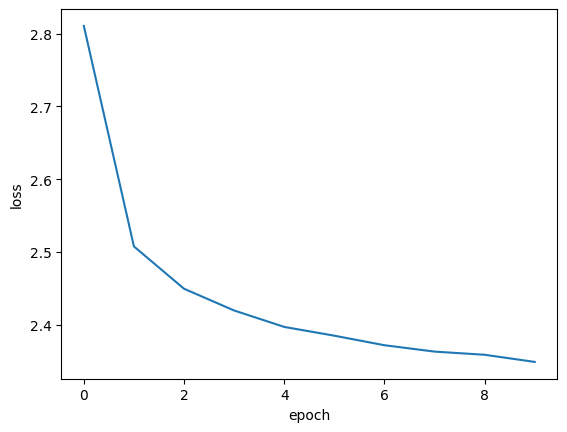

In [45]:
rnn = RNN(len(wi), n_dim=32)
lh = rnn_train(rnn, dataset, epochs=10, batch_size=32, lr=0.001)

The loss in our model is slightly worse than that of the previous model. This is true since we are using a context range of 4 tokens. But the advantage of this new architecture is that we can increase the context range without increasing the number of parameters. Let's increase the context range to 32 tokens and the embedding dimensions to 128 to see how it performs.

  0%|          | 0/1033090 [00:00<?, ?it/s]

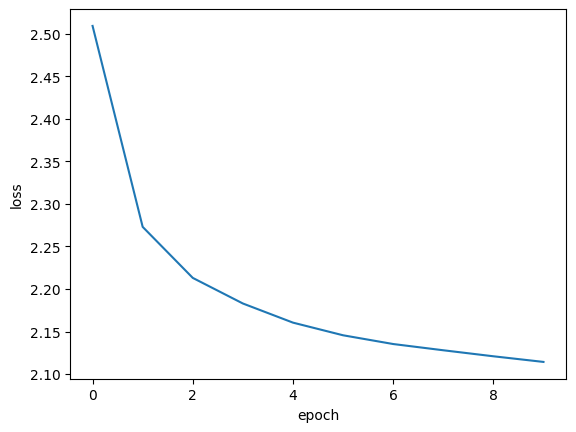

In [46]:
dataset = build_dataset(tokens, sequence_length=32, slide=1)

rnn = RNN(len(wi), n_dim=128)
lh = rnn_train(rnn, dataset, epochs=10, batch_size=32, lr=0.001)

It helps decrease the loss, but the training takes much more time due to the iterative nature of the architecture. Also, we need to test it with more epochs to see if it can reach a lower loss. For learning purposes lets reduce the dataset to a smaller size and take fewer tokens.

  0%|          | 0/393600 [00:00<?, ?it/s]

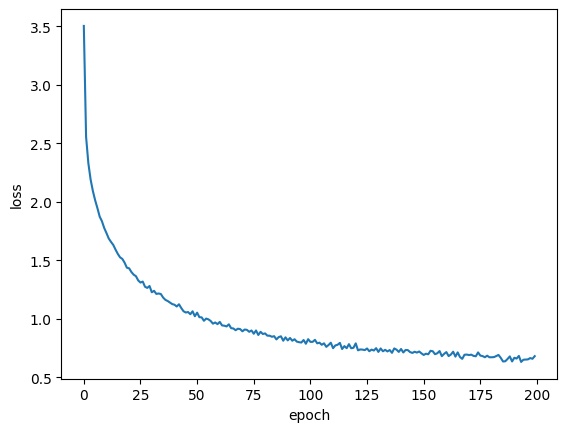

Last loss: 0.68


In [47]:
# using only 2000 tokens to increase training speed
dataset = build_dataset(tokens[:2000], sequence_length=32, slide=1)

rnn = RNN(len(wi), n_dim=128)
loss_history = rnn_train(rnn, dataset, epochs=200, batch_size=32, lr=0.001)
print(f'Last loss: {loss_history[-1]:.2f}')

We reached a much lower loss. Let's now use this model to generate text and see how it performs:

In [48]:
def gen_rnn(model, text, max_tokens=100):
    model.eval()
    state_embedding = model.init_hidden(1)

    text_tokens = [wi[c] for c in text]
    last_sequence = torch.LongTensor(text_tokens).unsqueeze(0)

    for _ in range(max_tokens):
        output, state_embedding = model(last_sequence, state_embedding)
        last_sequence = torch.multinomial(output[:, -1].exp(), 1)
        text += iw[last_sequence.item()]

    return text

text = 'Comp'

txt = gen_rnn(rnn, text, max_tokens=1000)
print(txt)

Computers as computer (IBM System, softimes. Early in to gerecor machine that consuse computers efartwha
Programmed toing somputers and computers as perspeecro digrtomatterm te computers and conputprone monitor)Superform generic see Conter 2)Desktop computers to right, top to gichar includes the Industrealermote contril divice which infullic s ered used onl users.
Early computers and conproframe computer (IBM System/360)Smartor)Superfoim s erions pattomA brial Revolution, somatica ly to buth controls, and used o long orichal genering Worl gialezed alctors and usad rangrial aloperations ffrs Early vacuum-tube computer (IBM System/360)Smartphone (LYF Water 2)Desktop computers tank different eres ted ondumis gusthe corputers and fucluses, seed dusproprene ne computers ta kefrrma
Early vacumauting cartog, ofe mechanical and used onl e arimat or eset, tot oink for th ingumer croputpes, sich rentren, one (LYF Water 2)Desktor)Supercomputers ardware, and usens as cha uially computer (IBM Syste

---

The model is able to generate better text, but it writes some words correctly, but not all. Also, the text hardly makes sense, and it tends to become worse the longer we generate.

RNNs have two well-known problems. The first one is that by increasing the number of tokens in the sequence, the gradients are going to be propagated through more time steps, and if it has a diminishing effect, it can start to be smaller in each step until it becomes zero in the initial steps, and we already know that with zero gradients our models don't learn. This is called the vanishing gradient problem. It is also possible to have the opposite effect, where the gradients become larger in each step until it becomes infinity. This is called the exploding gradient problem. We already are mitigating this problem by using a log softmax in the last layer. Computing the probabilities in the log space helps the gradients become stable in longer contexts.

Another problem is that the model needs to keep all information from the previous context in the state embedding. And by learning and generating longer texts, it is becoming harder and harder for the model to remember information from the start of the text. We can improve our architecture by adding to it a memory channel to better handle information.

## Long short-term memory networks

To improve our RNN architecture, we can add a memory channel to it. This channel will give the model the ability to selectively store information from the previous tokens. We will be inspired by the SR Latch circuit:

![](./img/srlatch.png)

The SR Latch is a simple circuit that has two inputs, S and R, and two outputs, Q and Q'. The S input is used to set the output Q to 1, while the R input is used to reset the output Q to 0. The output remains the same until one of the inputs is activated. Let's iteratively build this architecture, starting with the same RNN architecture we have already built and then adding the memory channel to it. This new architecture is called a Long Short-Term Memory network or LSTM for short.

Let's start with the model layers:

In [49]:
n_dims = 32
vocab_size = len(wi)

embedding_layer = nn.Embedding(len(wi), n_dims)

output_layer = nn.Sequential(
    nn.Linear(n_dims, vocab_size),
    nn.LogSoftmax(dim=-1)
)

state_layer = nn.Sequential(
    nn.Linear(n_dims, n_dims),
    nn.Tanh(),
    nn.Dropout(0.2),
)

Then the computing part:

In [50]:
current_token = torch.LongTensor([wi['C']])
state_embedding = torch.zeros((1, n_dims))

token_embedding = embedding_layer(current_token)
hidden_state = state_embedding + token_embedding

log_probs = output_layer(hidden_state)
new_state = state_layer(hidden_state)

Let's start by adding the memory channel. It is an embedding and operates in a similar way to the current state embedding.

In [51]:
current_token = torch.LongTensor([wi['C']])
state_embedding = torch.zeros((1, n_dims))
# new memory embedding
memory_embedding = torch.zeros((1, n_dims))

token_embedding = embedding_layer(current_token)
hidden_state = state_embedding + token_embedding

log_probs = output_layer(hidden_state)
new_state = state_layer(hidden_state)

Now we can add the set and reset operations to the memory. The decision of when to reset the memory and when to store new memory comes from the state and current token we have.

To implement the reset gate, we can multiply it by 0 to reset the memory and by 1 if we want to keep the memory. We can achieve this by passing our hidden state through a linear layer with a sigmoid activation function. The output of this layer will be between 0 and 1, and we can use it to multiply the memory embedding to reset it when needed.

So let's add the reset layer:

In [52]:
reset_layer = nn.Sequential(
    nn.Linear(n_dims, n_dims),
    nn.Sigmoid(),
)

Then we can compute the reset signal and multiply it by the memory embedding to reset it when needed:

In [53]:
reset_signal = reset_layer(hidden_state)
reset_memory_embedding = reset_signal * memory_embedding

A similar approach can be used to implement the set gate. But now the signal is the inverse; if the set signal is 1, we multiply our input by 1 and add it to the memory embedding, changing the memory embedding to a new value. If the set signal is 0, we multiply our input by 0, and that results in 0 being added to the memory embedding, so the memory embedding keeps the same value. Remember that those operations are applied per embedding dimension, so they can simultaneously set or reset different dimensions of the memory embedding.

Just before setting the memory, we don't want to directly add the hidden state and token to the memory embedding. To give more representation power, we want to first apply a transformation to it and then store it in memory. So we need two new layers: one for the set signal and the other for the memory value.

In [54]:
set_layer = nn.Sequential(
    nn.Linear(n_dims, n_dims),
    nn.Sigmoid(),
)

value_layer = nn.Sequential(
    nn.Linear(n_dims, n_dims),
    # using tanh to have a larger value range
    nn.Tanh(),
)

Now we compute the value embedding, multiply it by the set signal, and add it to the reset memory embedding to get the new memory embedding:

In [55]:
value_embedding = value_layer(hidden_state)
set_signal = set_layer(hidden_state)
new_memory = reset_memory_embedding + set_signal * value_embedding

To compute the new state, we also need to consider the computed memory embedding. So to compute the new state, we can use the same approach as before, but using our output layer as a gate to decide which information from memory goes into the new state. In this way, the new state is conditioned by both the previous state, the current token, and the memory embedding.

In this case, we will change the output layer to use a sigmoid activation function instead of a log softmax. And multiply it by the new memory. Since the new memory is already the combination of the previous memory and the new value, we can just use a tanh activation function on it to get the new state. The new state is computed as follows:

In [56]:
output_layer = nn.Sequential(
    nn.Linear(n_dims, n_dims),
    nn.Sigmoid()
)

new_state = output_layer(hidden_state) * torch.tanh(new_memory)

Putting everything together inside a module, we have the new architecture:

In [57]:
class LSTMLayer(nn.Module):
    def __init__(self, n_dims=64):
        super(LSTMLayer, self).__init__()

        self.reset_layer = nn.Sequential(
            nn.Linear(n_dims, n_dims),
            nn.Sigmoid(),
            nn.Dropout(0.2),
        )

        self.set_layer = nn.Sequential(
            nn.Linear(n_dims, n_dims),
            nn.Sigmoid(),
            nn.Dropout(0.2),
        )

        self.value_layer = nn.Sequential(
            nn.Linear(n_dims, n_dims),
            nn.Tanh(),
            nn.Dropout(0.2),
        )

        self.output_layer = nn.Sequential(
            nn.Linear(n_dims, n_dims),
            nn.Sigmoid(),
            nn.Dropout(0.2),
        )

    def forward(self, x, state, memory):

        hidden_state = x + state

        # resetting the memory
        reset_signal = self.reset_layer(hidden_state)
        reset_memory = reset_signal * memory

        # setting the memory
        set_signal = self.set_layer(hidden_state)
        value = self.value_layer(hidden_state)
        new_memory = reset_memory + set_signal * value

        # output and new state
        output = self.output_layer(hidden_state)
        new_state = output * torch.tanh(new_memory)

        return output, new_state, new_memory

We can further upgrade our model by stacking multiple LSTM layers on top of each other. Most of the success of deep learning comes from the ability to build deeper layered architectures. By stacking those layers, each one will have the capacity to build higher levels of representation with each layer. For example, the first layer can learn to get the grammatical class of the tokens, and with higher layers, we can learn more complex and semantic representations. Note that those representations are learned in an unsupervised way by the model by just learning to predict the next token.

Let's build the final model with multiple LSTM layers and an output layer to compute the next token probabilities:

In [58]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, n_dims=64, layers=2):
        super(LSTM, self).__init__()

        self.embedding_layer = nn.Embedding(vocab_size, n_dims)
        self.dropout = nn.Dropout(0.2)
        # stacking multiple LSTM layers
        self.lstm_layers = nn.ModuleList([LSTMLayer(n_dims=n_dims) for _ in range(layers)])

        self.lm_head = nn.Sequential(
            nn.Linear(n_dims, vocab_size),
            nn.LogSoftmax(dim=-1)
        )

        self.n_dims = n_dims
        self.layers = layers

    def forward(self, x, state, memory):
        emb = self.dropout(self.embedding_layer(x))

        output = []
        for i in range(emb.shape[1]):
            ei = emb[:, i]
            lh = []
            lm = []
            # we iterate over all layers for each token
            for j, layer in enumerate(self.lstm_layers):
                ei, nh, nm = layer(ei, state[:, j], memory[:, j])
                lh.append(nh)
                lm.append(nm)
            state = torch.stack(lh, dim=1)
            memory = torch.stack(lm, dim=1)
            output.append(self.lm_head(ei).unsqueeze(1))

        return torch.cat(output, dim=1), state, memory

    # now we also need to start the memory
    def start_mem(self, batch_size):
        state = torch.zeros((batch_size, self.layers, self.n_dims))
        memory = torch.zeros((batch_size, self.layers, self.n_dims))
        return state, memory

And that's it, we have our LSTM architecture. Now we can train it with a similar training loop as the RNN. The main difference is that we also need to initialize the memory at the beginning of each batch.

In [59]:
def lstm_train(model, dataset, epochs=10, batch_size=16, lr=0.01, plot=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss()

    progress = tqdm(total=len(dataset) * epochs)
    lh = []
    for _ in range(epochs):
        el = []
        for (x, y) in DataLoader(dataset, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            h, m = model.start_mem(x.shape[0])
            o, _, _ = model(x, h, m)
            loss = crit(o[:, -1], y)

            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    if plot:
        plt.plot(lh)
        plt.xlabel('epoch')
        plt.ylabel('loss')
        plt.show()
    return lh

  0%|          | 0/393600 [00:00<?, ?it/s]

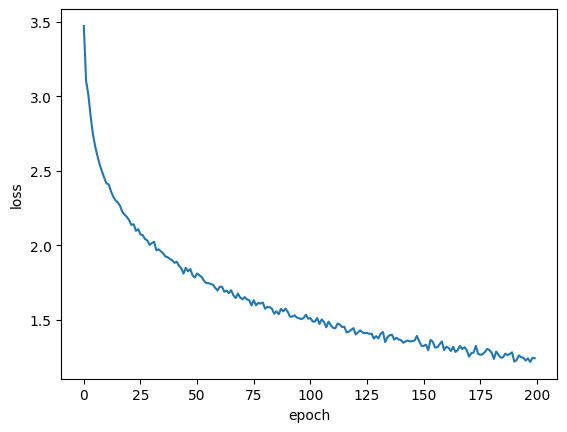

1.2395125810177094


In [60]:
dataset = build_dataset(tokens[:2000], sequence_length=32, slide=1)

lstm = LSTM(len(wi), n_dims=128, layers=2)
lh = lstm_train(lstm, dataset, epochs=200, batch_size=32, lr=0.001)
print(lh[-1])

This time, we got a higher loss than the RNN. In fact, we are underutilizing our data with our current training approach. We are only using the last token of the output to compute the loss, but we can use all the tokens in the sequence to compute the loss.

![](./img/lstm.png)

We can also compute the loss of the previous tokens in the sequence. From the example above, we can see that the model outputs are just the input tokens shifted by one.

Let's rebuild our dataset and training loop:

In [61]:
def build_dataset(tokens, sequence_length=1, slide=1):

    x = []

    for i in range(0, len(tokens) - sequence_length, slide):
        x.append([wi[q] for q in tokens[i:i+sequence_length]])

    return TensorDataset(torch.LongTensor(x))

dataset = build_dataset(tokens[:2000], sequence_length=32, slide=1)
print(len(dataset))
print(dataset[0][0].shape)

1968
torch.Size([32])


In [62]:
def lstm_train(model, dataset, epochs=10, batch_size=16, lr=0.01):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    crit = nn.NLLLoss()

    progress = tqdm(total=len(dataset) * epochs)
    lh = []
    for _ in range(epochs):
        el = []
        for (x, ) in DataLoader(dataset, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            h, m = model.start_mem(x.shape[0])
            o, _, _ = model(x, h, m)
            loss = crit(torch.flatten(o[:, :-1], start_dim=0, end_dim=-2), torch.flatten(x[:, 1:], start_dim=0))

            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()
    return lh

  0%|          | 0/393600 [00:00<?, ?it/s]

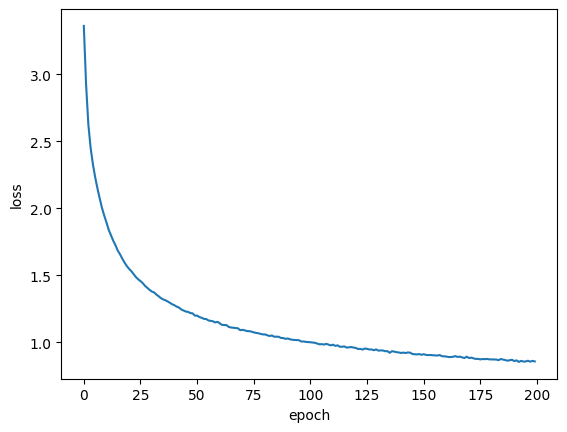

0.8572987837176169


In [63]:
dataset = build_dataset(tokens[:2000], sequence_length=32, slide=1)

lstm = LSTM(len(wi), n_dims=128, layers=2)
lh = lstm_train(lstm, dataset, epochs=200, batch_size=32, lr=0.001)
print(lh[-1])

The training takes almost the same time, and we got a much lower loss. Let's see how it performs in generating text:

In [64]:
def gen_lstm(model, s, max_tokens=100):
    model.eval()
    h, m = model.start_mem(1)
    si = [wi[c] for c in s]
    lt = torch.LongTensor(si).unsqueeze(0)

    for _ in range(max_tokens):
        o, h, m = model(lt, h, m)
        lt = torch.multinomial(o[:, -1].exp(), 1)
        s += iw[lt.item()]

    return s

s = 'Comp'

txt = gen_lstm(lstm, s, max_tokens=1000)
print(txt)

Computers and for looms. More for looms. The first did special-purpose devices fere eras—left to re of grncesses on and for looms. The to be used for lattions (computers and for the eras—left to bottom:
Early can perform a widiom, which linked and used only computer (IBM Sytrial refer to bottom:
Early volutions (computer network or logical operating Wart, see Computer (IBM Summit)
A broad range of computers and used only 20th century. Modern differame computer (IBM Summit)
A computer system may refer the Internet, such as guiding digital electromically can perform general-purpose devices of group of computers and remate consumer arithmeth cinsumer ured devices first such as personal computer (IBM System/360)Smartphones from computation).
Early vacuum-tube computers and peripheral operations. S50 with micrammable special-purpose devices which linked a computers and used for use system/360)Smartphones. Moder 2)Desktop computer systems, see Procats used operating system may refer the Indu

---

The model still struggles to produce a coherent text and writes some words incorrectly. However, it keeps the generation quality stable for longer.

In language models, we often have a trade-off in the tokenization process. If we use a character-level tokenization, the model is able to represent almost any text, since with the alphabet, we can represent any word in that language. However, it is harder for the model to learn how to reconstruct words since it will need more data, parameters, and iterations. We can sacrifice some generability by increasing the n-gram size, consequently increasing our vocabulary size and reducing the model effort to model our training data. Let's conduct this experiment and see how the text quality changes if we increase the n-gram size to 2 and still train with 2000 tokens.

  0%|          | 0/196800 [00:00<?, ?it/s]

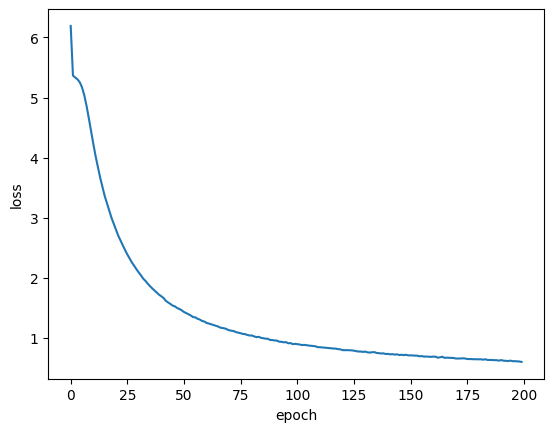

0.6028361051313339


In [65]:
n_grams = 2
tokens = tokenize(cleaned_text, n_grams, False)
wi, iw = build_vocab(tokens)

dataset = build_dataset(tokens[:2000], sequence_length=32, slide=n_grams)

lstm = LSTM(len(wi), n_dims=128, layers=2)
lh = lstm_train(lstm, dataset, epochs=200, batch_size=32, lr=0.001)
print(lh[-1])

In [66]:
s = tokenize('Computer', n_grams, False)
txt = gen_lstm(lstm, s, max_tokens=1000)
print(''.join(txt))

Computer (IBM System/360)Smartphone (LYF Water 2)Desktop computer was in a different eras—left to right, top to bottom:
Early vacuum-tube computers and computing devices from different sense, in a 1613 book called The Yong Mans Gleanings by the English writer Richard Brathwait: "I haue  [sic] read the term referred to automate long, tedious tasks, such as guiding World War II, both electromechanical and using the late 1940s were followed by the silicon-based MOSFET (MOS transistor) and monolithic integrated circuit chip technologies in the late 1950s, leading to the Digital Revolution during the late 1940s were followed by the form of a microscope and calculator, 1952
It was not until the ordevices such as personal computer was in a different eras—left to right, top to bottom:
Early in the form of a microscope and calculator, 1952
It was not until the mid-20th century. The first digital electronic calculations. Simple manual instruments like the 1970s. The processes data
For the consum

---

Increasing the n-gram greatly increased the text quality. The highest perception is that the number of wrong words is much smaller. However, even when trained in a sequence size of 32 tokens, the model is still able to write correct words over a long range.

## Conclusion

We saw in this chapter how we solved the problem of long-range dependencies in the Markov chains using deep learning to build architectures capable of learning from data. We started by building a simple architecture and interactively improving it to reach the LSTM architecture, one of the most influential models in sequence modeling.

However, as we already saw, LSTMs are very inefficient to train due to their iterative nature. In the next chapter, we will see how to increase the training efficiency by introducing a new architecture called Transformer that is based on the attention mechanism and is the basis of the most powerful language models at the time.